In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

In [2]:
import neuroboros as nb
import numpy as np
from scipy.stats import ttest_rel

In [3]:
results = nb.load('summary/isc_dallas.pkl')

In [4]:
list(results)

[('young', 'young'),
 ('mid', 'young'),
 ('old', 'young'),
 ('young', 'mid'),
 ('mid', 'mid'),
 ('old', 'mid'),
 ('young', 'old'),
 ('mid', 'old'),
 ('old', 'old')]

In [5]:
for test_grp in ['old', 'young']:
    for tpl_grp in ['old', 'young']:
        print(results[test_grp, tpl_grp].shape)

(10, 182, 19341)
(10, 182, 19341)
(10, 92, 19341)
(10, 92, 19341)


In [6]:
zz = {}
for test_grp in ['old', 'young']:
    for tpl_grp in ['old', 'young']:
        res = results[test_grp, tpl_grp]
        zz[test_grp, tpl_grp] = np.arctanh(res).mean(axis=(0, 1))

In [33]:
a = np.tanh(zz['old', 'old'])
b = np.tanh(zz['old', 'young'])
c = zz['old', 'old'] - zz['old', 'young']
for d in [a, b, c]:
    nb.percentile(d)

[0.16099084 0.35762513 0.41717567 0.4672156  0.50509945 0.54678237
 0.5867856  0.6176506  0.64313503 0.67152388 0.74756363]
[0.16379412 0.34948197 0.41232706 0.46192539 0.5012509  0.54659603
 0.58611396 0.61644612 0.64357189 0.67388242 0.75351198]
[-0.02999666 -0.01468531 -0.01061512 -0.00617088 -0.00144699  0.00290179
  0.00678346  0.01040907  0.01419839  0.01914516  0.05090095]


In [34]:
vmax = 1
ia = nb.plot(a, vmax=vmax, vmin=-vmax, cmap='bwr', title = "ISC of older adults (congruent)", label='$r$')
ib = nb.plot(b, vmax=vmax, vmin=-vmax, cmap='bwr', title = "ISC of older adults (incongruent)", label='$r$')
vmax = 0.2
ic = nb.plot(c, vmax=vmax, vmin=-vmax, cmap='bwr', title = "ISC difference (congruent - incongruent)", label='$z$ difference')
nb.Image.hstack([ia, ib, ic]).save('figures/isc_map_dallas_older.png')

In [30]:
a = np.tanh(zz['young', 'young'])
b = np.tanh(zz['young', 'old'])
c = zz['young', 'young'] - zz['young', 'old']
for d in [a, b, c]:
    nb.percentile(d)

[0.14858799 0.42021939 0.49092796 0.54460131 0.59162505 0.62500541
 0.65103218 0.67430235 0.70189054 0.73531811 0.82763112]
[0.14439602 0.42138271 0.48993479 0.54253737 0.58794928 0.62110178
 0.64687714 0.67003595 0.6968756  0.73048023 0.82005285]
[-0.02440944 -0.00659503 -0.00212197  0.00117265  0.00393898  0.00628828
  0.0082811   0.01024447  0.0123754   0.01532142  0.03569558]


In [31]:
vmax = 1
ia = nb.plot(a, vmax=vmax, vmin=-vmax, cmap='bwr', title = "ISC of younger adults (congruent)", label='$r$')
ib = nb.plot(b, vmax=vmax, vmin=-vmax, cmap='bwr', title = "ISC of younger adults (incongruent)", label='$r$')
vmax = 0.2
ic = nb.plot(c, vmax=vmax, vmin=-vmax, cmap='bwr', title = "ISC difference (congruent - incongruent)", label='$z$ difference')
nb.Image.hstack([ia, ib, ic]).save('figures/isc_map_dallas_younger.png')

[-0.00343751 -0.00105838 -0.00028313  0.00038836  0.00093466  0.00143532
  0.00197228  0.00257014  0.00325379  0.00425348  0.00958914]


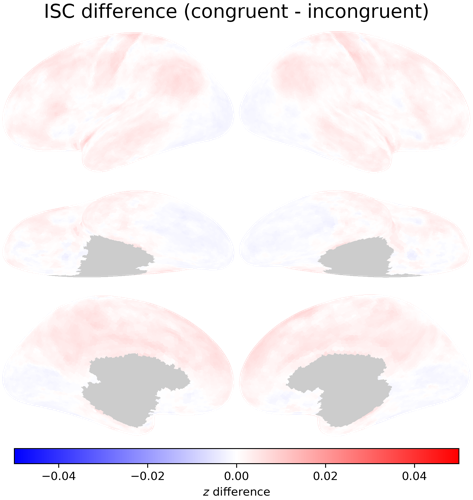

In [41]:
c = ((zz['young', 'young'] - zz['young', 'old']) + (zz['old', 'old'] - zz['old', 'young'])) * 0.2
nb.percentile(c)
vmax = 0.05
ic = nb.plot(c, vmax=vmax, vmin=-vmax, cmap='bwr', title = "ISC difference (congruent - incongruent)", label='$z$ difference')
ic.save('figures/isc_map_dallas_average.png')
ic

In [85]:
mako = np.array(sns.color_palette('mako', 7))
rocket = np.array(sns.color_palette('rocket', 7))
colors = np.concatenate([
    mako[1:],
    [mako[-1] * 0.5 + 0.5],
    [[1, 1, 1]],
    [rocket[-1] * 0.5 + 0.5],
    rocket[1:][::-1],
])
print(colors)
# cmap = mpl.colors.ListedColormap(colors)
cmap = mpl.colors.LinearSegmentedColormap.from_list('mako_rocket', list(colors))

[[0.24423453 0.20678459 0.41985299]
 [0.23318874 0.33648036 0.59775543]
 [0.20692679 0.48201774 0.63812656]
 [0.20795035 0.62210845 0.66867802]
 [0.29215894 0.76144162 0.67886578]
 [0.60028928 0.86793835 0.71523675]
 [0.80014464 0.93396917 0.85761837]
 [1.         1.         1.        ]
 [0.98296414 0.86922129 0.80026995]
 [0.96592829 0.73844258 0.60053991]
 [0.95922872 0.53307513 0.3748895 ]
 [0.92676657 0.29823282 0.24285536]
 [0.7965014  0.10506637 0.31063031]
 [0.59096382 0.10810205 0.35847347]
 [0.38092887 0.12061482 0.32506528]]


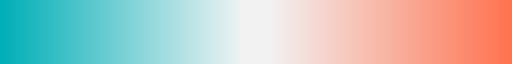

In [94]:
cmap = sns.diverging_palette(200, 20, s=100, l=65, sep=16, as_cmap=True)
cmap

[-0.00343751 -0.00105838 -0.00028313  0.00038836  0.00093466  0.00143532
  0.00197228  0.00257014  0.00325379  0.00425348  0.00958914]


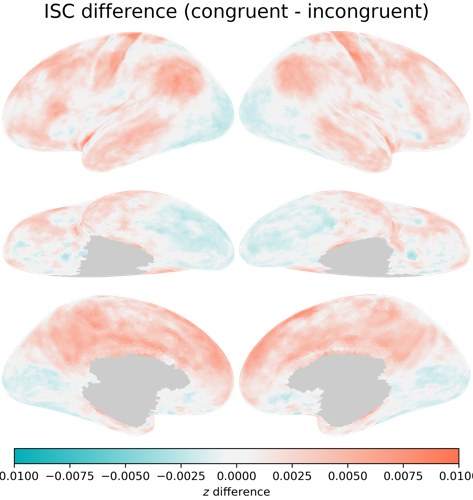

In [95]:
c = ((zz['young', 'young'] - zz['young', 'old']) + (zz['old', 'old'] - zz['old', 'young'])) * 0.2
nb.percentile(c)
vmax = 0.01
ic = nb.plot(c, vmax=vmax, vmin=-vmax, cmap=cmap, title = "ISC difference (congruent - incongruent)", label='$z$ difference')
ic.save('figures/isc_map_dallas_average.png')
ic

In [72]:
ic[1]

In [64]:
type(plt.get_cmap('bwr'))

matplotlib.colors.LinearSegmentedColormap

In [66]:
type(plt.get_cmap(cmap))

matplotlib.colors.ListedColormap

In [70]:
cmap(np.zeros((3, 3)))

array([[[0.24423453, 0.20678459, 0.41985299, 1.        ],
        [0.24423453, 0.20678459, 0.41985299, 1.        ],
        [0.24423453, 0.20678459, 0.41985299, 1.        ]],

       [[0.24423453, 0.20678459, 0.41985299, 1.        ],
        [0.24423453, 0.20678459, 0.41985299, 1.        ],
        [0.24423453, 0.20678459, 0.41985299, 1.        ]],

       [[0.24423453, 0.20678459, 0.41985299, 1.        ],
        [0.24423453, 0.20678459, 0.41985299, 1.        ],
        [0.24423453, 0.20678459, 0.41985299, 1.        ]]])

In [80]:
mpl.colors.LinearSegmentedColormap?

Init signature: mpl.colors.LinearSegmentedColormap(name, segmentdata, N=256, gamma=1.0)
Docstring:     
Colormap objects based on lookup tables using linear segments.

The lookup table is generated using linear interpolation for each
primary color, with the 0-1 domain divided into any number of
segments.
Init docstring:
Create colormap from linear mapping segments

segmentdata argument is a dictionary with a red, green and blue
entries. Each entry should be a list of *x*, *y0*, *y1* tuples,
forming rows in a table. Entries for alpha are optional.

Example: suppose you want red to increase from 0 to 1 over
the bottom half, green to do the same over the middle half,
and blue over the top half.  Then you would use::

    cdict = {'red':   [(0.0,  0.0, 0.0),
                       (0.5,  1.0, 1.0),
                       (1.0,  1.0, 1.0)],

             'green': [(0.0,  0.0, 0.0),
                       (0.25, 0.0, 0.0),
                       (0.75, 1.0, 1.0),
                       (1.0,